In [250]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings("ignore")

In [251]:
df = pd.read_csv('../20_02_2026_Friday/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [252]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [253]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [254]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [255]:
df.describe()  #this-gives us statistics summary

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [256]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [257]:
df[df.duplicated()]  #this is the duplicated-row

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [258]:
df.drop_duplicates(keep='first', inplace=True)         #keep='first' delete the second occurrence of similar row

In [259]:
df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [260]:
df['children'].value_counts()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [261]:
df['region'].value_counts()
#df['region'].mode()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

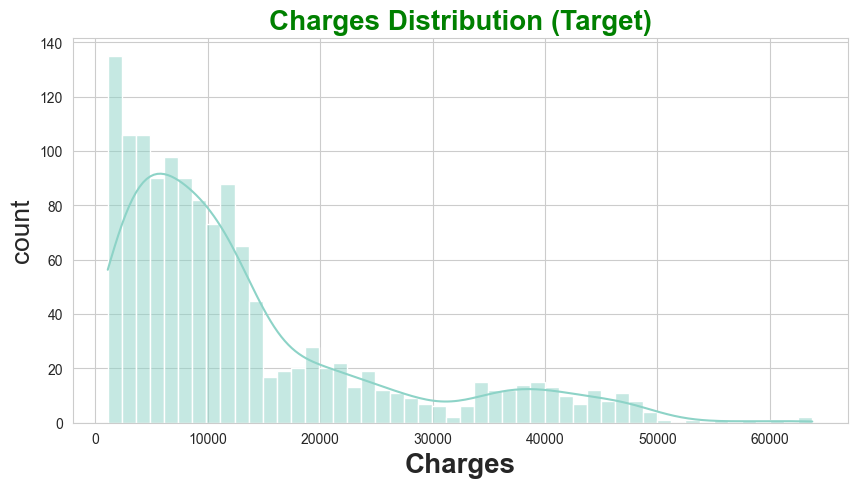

In [262]:
# Histogram-plot for Target-column
sns.set_style('whitegrid')
plt.figure(figsize=(10,5))
sns.histplot(df['charges'], bins=50, kde=True, palette='dark')
plt.title('Charges Distribution (Target)', fontsize=20, weight='bold', color='green')
plt.xlabel('Charges', fontsize=12)
plt.ylabel('count', fontsize=19)
plt.xlabel('Charges', fontsize=20, weight='bold')
plt.show()

<Figure size 2000x1500 with 0 Axes>

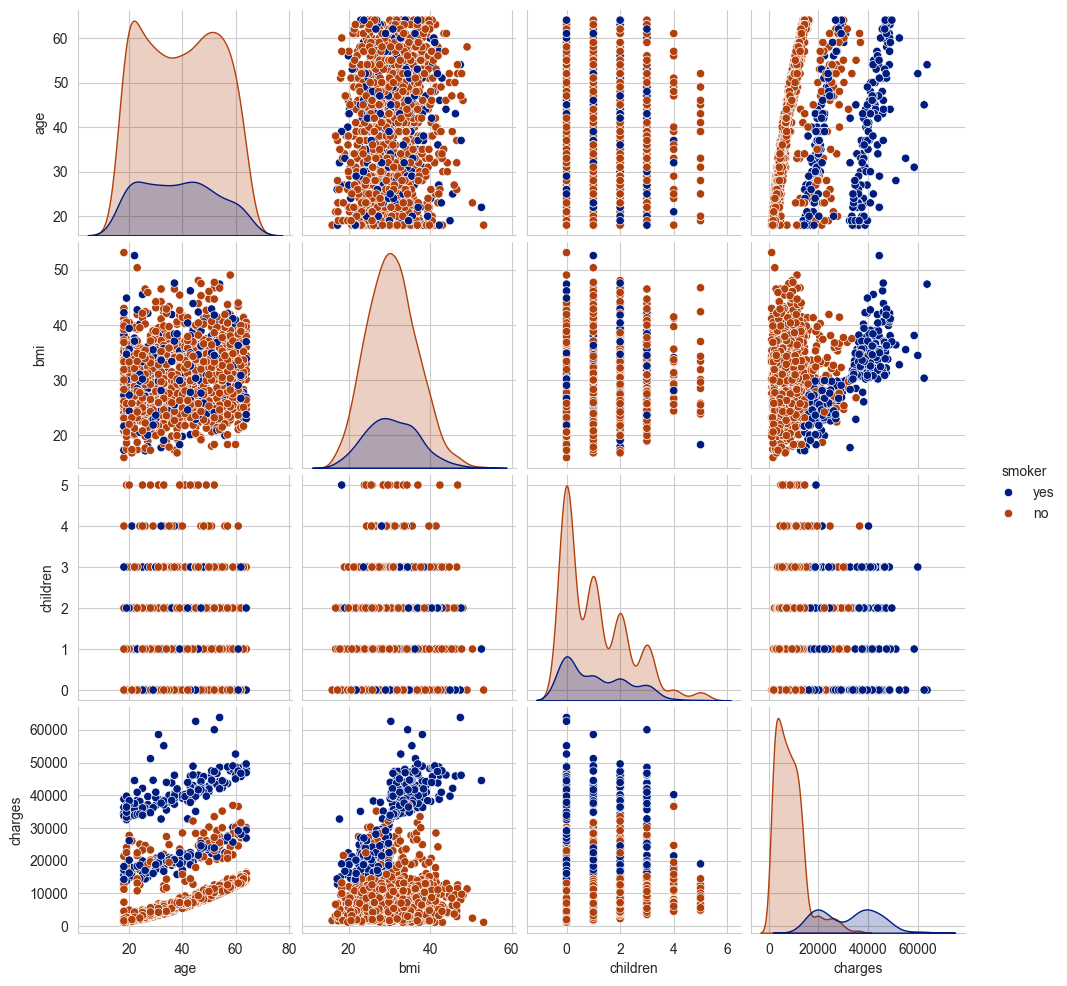

In [263]:
plt.figure(figsize=(20,15))
sns.pairplot(df, hue='smoker' ,palette='dark')
plt.show()

* this-basically shows the entire dataset comparing numerical features distribution in-one go!

In [264]:
corr = df.corr(numeric_only=True) # shows-correlation of one-feature with another (only-numeric columns)
corr

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


[]

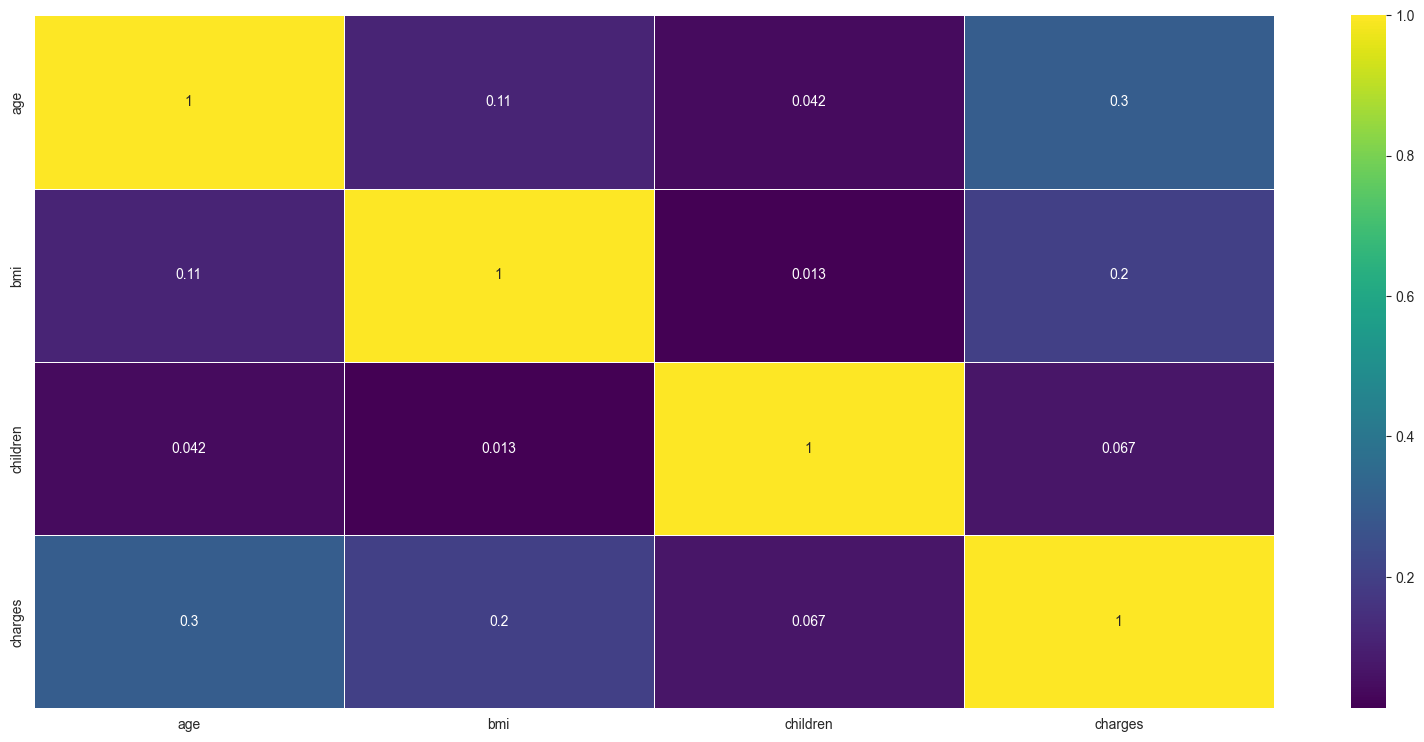

In [265]:
#heatmap, shows correlation
plt.figure(figsize=(20,9))
sns.heatmap(corr, annot=True, cmap='viridis',linewidths=0.5)
plt.plot()

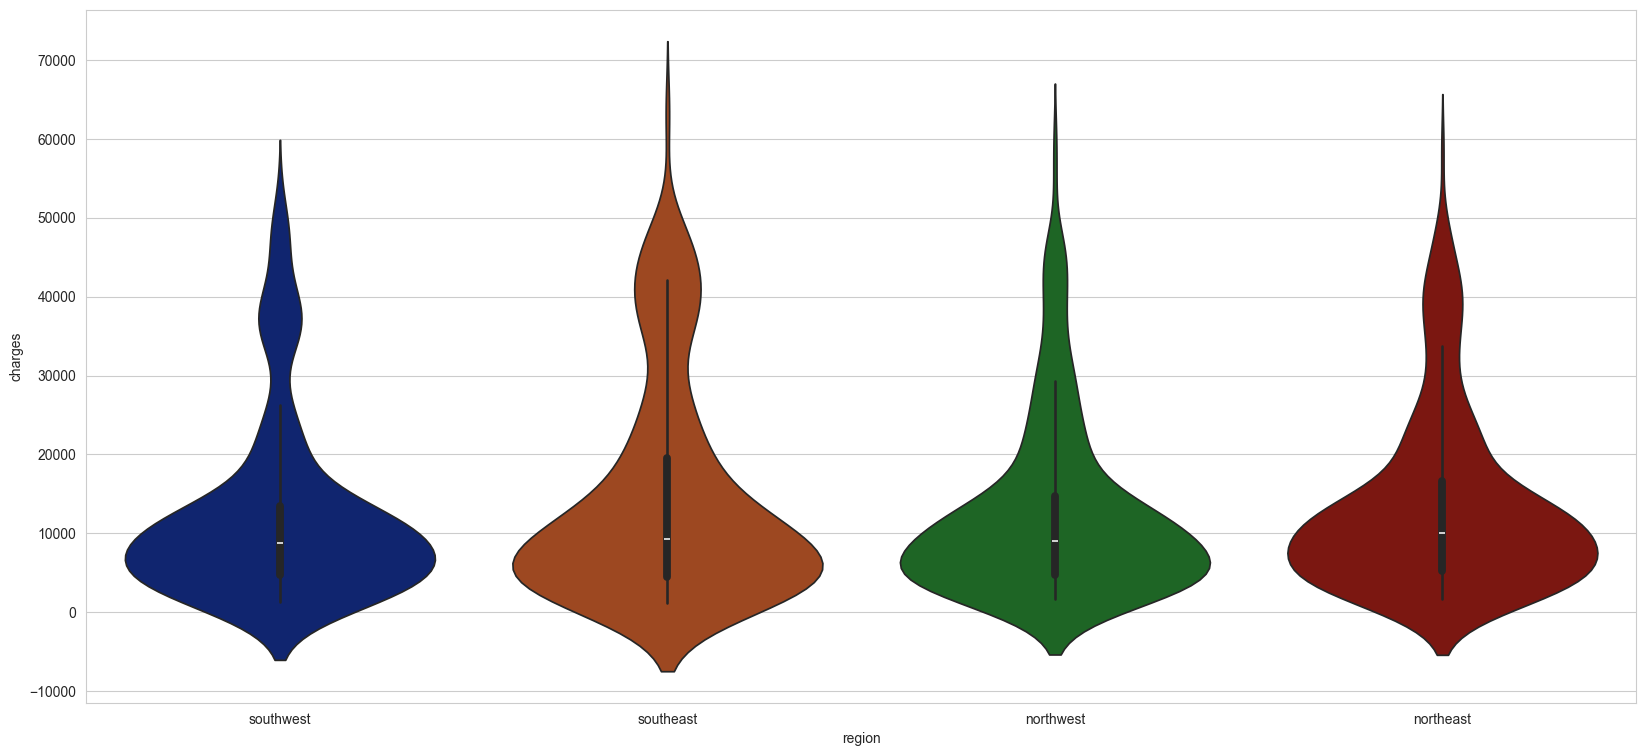

In [266]:
plt.figure(figsize=(20,9))
sns.violinplot(x='region',y='charges', data=df, palette='dark')
plt.show()

* The fat-part shows the most of the data point is situated there!
* The thin-part shows that there are outliers, because very few data-points exists on that portion!

**********************************************************************************************

In [267]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [268]:
df['sex'] = df['sex'].astype(object)
df['smoker'] = df['smoker'].astype(object)
df['region'] = df['region'].astype(object)

In [269]:
# q1 = df['bmi'].quantile(0.25)
# q3 = df['bmi'].quantile(0.75)
# IQR = q3-q1
#
# lower_fence = q1-1.5*IQR
# upper_fence = q3+1.5*IQR
#
# df['bmi'] = df['bmi'].clip(lower=lower_fence, upper=upper_fence)


In [270]:
num_feat = [cols for cols in df.columns if df[cols].dtypes != 'object' and cols != 'charges']
print(num_feat)

['age', 'bmi', 'children']


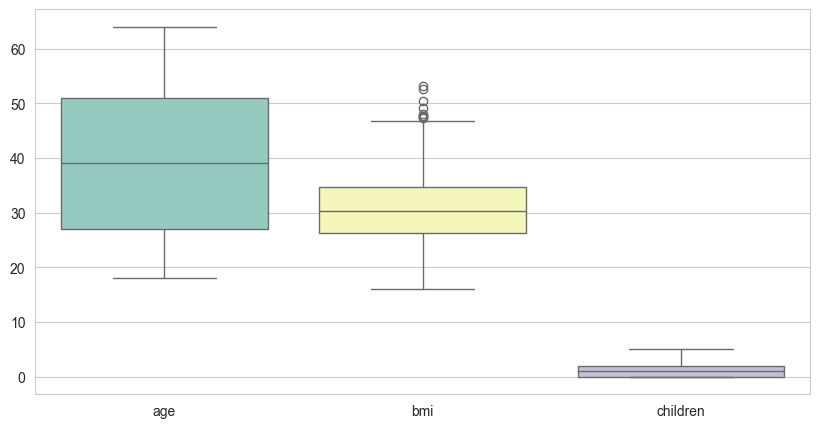

In [271]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[num_feat])
plt.show()

In [272]:
# this-is-how we treat the outlier
for cols in num_feat:
    q1 = df[cols].quantile(0.25)
    q3 = df[cols].quantile(0.75)
    IQR = q3-q1

    lower_fence = q1-1.5*IQR
    upper_fence = q3+1.5*IQR

    df[cols]= df[cols].clip(lower=lower_fence, upper=upper_fence)

In [273]:
# separated Numeric and categorical column
cat_features = [cols for cols in df.columns if df[cols].dtypes == 'object']
num_features = [cols for cols in df.columns if df[cols].dtypes != 'object' and cols != 'charges']
print(cat_features)
print(num_features)

['sex', 'smoker', 'region']
['age', 'bmi', 'children']


In [274]:
x = df.iloc[:, :-1]   #features
y = df.iloc[:, -1]    #target

In [275]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1, shuffle=True)

In [276]:
x_train.shape , x_test.shape

((1069, 6), (268, 6))

In [277]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
x_train_cat = ohe.fit_transform(x_train[cat_features])
x_test_cat = ohe.transform(x_test[cat_features])
print(x_train_cat, x_test_cat)

[[1. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 ...
 [1. 0. 0. 1. 0.]
 [0. 1. 0. 1. 0.]
 [1. 1. 0. 1. 0.]] [[0. 1. 1. 0. 0.]
 [1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 1. 0.]
 [0. 0. 1. 0. 0.]]


In [278]:
x_train_cat = pd.DataFrame(x_train_cat, columns=ohe.get_feature_names_out(cat_features), index=x_train.index)
x_test_cat = pd.DataFrame(x_test_cat, columns=ohe.get_feature_names_out(cat_features), index=x_test.index)

In [279]:
scaler = StandardScaler()
x_train_num = scaler.fit_transform(x_train[num_features])
x_test_num = scaler.transform(x_test[num_features])
print(x_train_num, x_test_num)

[[ 1.48940652  0.42043395  1.58555017]
 [ 1.48940652 -1.10355438 -0.9205412 ]
 [ 0.63151478 -0.54517849 -0.08517741]
 ...
 [-1.22725064  0.53126946 -0.9205412 ]
 [ 0.05958696 -1.40835204  0.75018638]
 [ 1.41791554  1.76893271 -0.08517741]] [[ 3.45550872e-01  1.40116032e+00 -9.20541203e-01]
 [ 1.27493358e+00  1.56779768e-01 -9.20541203e-01]
 [ 1.13195163e+00  3.00362139e-01 -8.51774118e-02]
 [-1.19040169e-02  1.87976822e+00 -9.20541203e-01]
 [ 1.31077939e-01  1.62115202e+00 -9.20541203e-01]
 [-1.01277771e+00 -1.19927596e+00 -9.20541203e-01]
 [-1.29874162e+00  1.04850186e+00 -9.20541203e-01]
 [ 1.13195163e+00 -8.80204023e-01  1.58555017e+00]
 [ 1.27493358e+00 -1.24713675e+00 -9.20541203e-01]
 [ 9.17478696e-01 -1.05569359e+00  1.58555017e+00]
 [ 1.48940652e+00 -1.02042774e+00 -9.20541203e-01]
 [-8.33949948e-02 -1.59307790e+00  1.58555017e+00]
 [ 9.88969673e-01 -2.89920942e-01 -9.20541203e-01]
 [ 4.17041850e-01 -9.12111217e-01  7.50186379e-01]
 [-1.51321455e+00  6.42104976e-01 -9.20541203e

In [280]:
x_train_num = pd.DataFrame(x_train_num, columns=num_features , index=x_train.index)
x_test_num = pd.DataFrame(x_test_num, columns=num_features, index=x_test.index)

In [281]:
x_train = pd.concat([x_train_num,x_train_cat], axis=1)
x_test = pd.concat([x_test_num,x_test_cat], axis=1)

In [282]:
regressor = LinearRegression()
regressor.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [283]:
y_pred = regressor.predict(x_test)

In [284]:
mse = mean_squared_error(y_test, y_pred)
print(f" Mean Squared Error: {mse}")

 Mean Squared Error: 32413037.364048623


In [285]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 3935.9511663927733


In [286]:
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

R2 Score: 0.7494350520799875


In [288]:
rmse = root_mean_squared_error(y_test, y_pred)
print(rmse)

5693.244888817679
